# EnrichMap supports user defined gene weights

This tutorial demonstrates how to use `EnrichMap` if the pathway of interest has gene wights information.

In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

Import required packages for minimal example.

In [ ]:
import scanpy as sc
import enrichmap as em

In [4]:
sc.set_figure_params(frameon=False)

Read in the dataset:

In [5]:
adata = sc.read(
    "adata_breast.h5ad",
    backup_url="https://github.com/secrierlab/EnrichMap/raw/main/tests/dataset/adata_breast.h5ad",
)

As the data shared with raw counts, we normalise the counts.

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

Here, we investigate EGFR pathway in breast cancer. The weighted gene signature is taken from [Schubert et al (2018)](https://www.nature.com/articles/s41467-017-02391-6).

In [7]:
nested_dict = {
    "EGFR pathway": {
        "DUSP6": 12.62931259,
        "DUSP5": 7.943039507,
        "FOSL1": 7.647829795,
        "DUSP4": 6.967179671,
        "PHLDA1": 6.619626129,
        "EGR3": 6.271415501,
        "EPHA2": 5.411184102,
        "ODC1": 4.678550829,
        "PNP": 4.643619942,
        "SPOCD1": 4.295689401,
        "TUBB4B": 4.084510208,
        "LAMC2": 3.920115723,
        "TRIB1": 3.917794383,
        "PTHLH": 3.613976653,
        "PHLDA2": 3.505138341,
        "PLEK2": 3.439256964,
        "AEN": 2.987402897,
        "EGR4": 2.953076385,
        "HAS3": 2.923737765,
        "BZW1": 2.746151949,
        "SH2D5": 2.432132976,
        "DSPP": 2.350387113,
        "SLC45A3": 1.902438902,
        "SPATA2L": 1.756497668,
        "MYEOV": 1.726632434,
        "HMOX2": 1.719637973,
        "VPS9D1-AS1": 1.601747009,
        "KCNF1": 1.57587573,
        "LOC101927363": 1.510406613,
        "XRCC3": 1.487957075,
        "DCAF13": 1.434232957,
        "LOC105375839": 1.428616839,
        "CFL1": 1.329245479,
        "ADORA1": 1.267810008,
        "PWP2": 1.172488384,
        "MDFI": 1.160109073,
        "GPR75": 1.037039515,
        "TUBB7P": 0.99687917,
        "MYO1A": 0.99477812,
        "CBARP": 0.979442479,
        "EXD3": 0.779924513,
        "TRH": 0.771964661,
        "CHRNA10": 0.6899809,
    }
}

### EnrichMap

We now calculate `EnrichMap` scores for the EGFR pathway. As there are more than one slide in this dataset, we specify the batch information stored in `adata.obs`. Note that, when using weighted signatures, we use `gene_weights` not `gene_set` argument.

In [8]:
em.tl.score(
    adata,
    gene_weights=nested_dict,
    batch_key="batch"
)

Scoring EGFR pathway: 34/43 genes found: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]


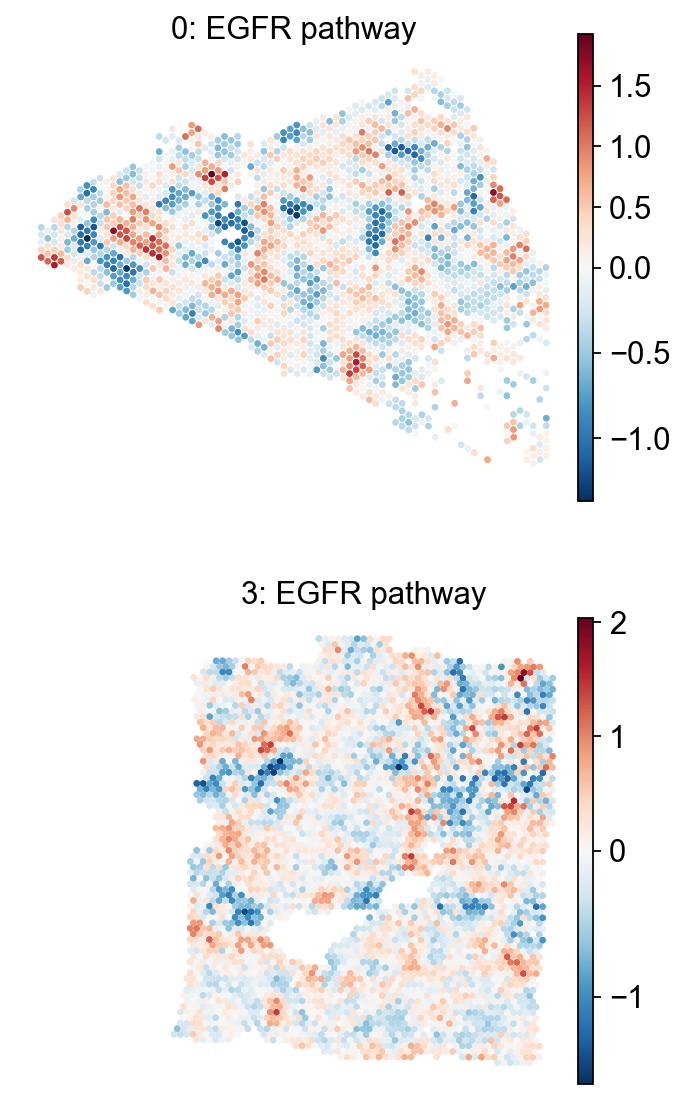

In [9]:
em.pl.spatial_enrichmap(
    adata,
    score_key=["EGFR pathway_score"],
    size=2,
    library_key="batch",
    library_id=["0", "3"],
    cmap="RdBu_r",
    shape=None
)